In [3]:
# ==========================================================
# Libraries
# ==========================================================

import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler
from sklearn.preprocessing import LabelEncoder

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    confusion_matrix,
    classification_report,
    roc_curve
)

import pickle

plt.style.use("ggplot")

pd.set_option("display.max_columns",None)

pd.set_option("display.max_rows",100)

In [4]:
# ==========================================================
# Read Dataset
# ==========================================================

df = pd.read_csv("alzheimers_disease_data.csv")

print(df.shape)

df.head()

(2149, 35)


,PatientID,Age,Gender,Ethnicity,EducationLevel,BMI,Smoking,AlcoholConsumption,PhysicalActivity,DietQuality,SleepQuality,FamilyHistoryAlzheimers,CardiovascularDisease,Diabetes,Depression,HeadInjury,Hypertension,SystolicBP,DiastolicBP,CholesterolTotal,CholesterolLDL,CholesterolHDL,CholesterolTriglycerides,MMSE,FunctionalAssessment,MemoryComplaints,BehavioralProblems,ADL,Confusion,Disorientation,PersonalityChanges,DifficultyCompletingTasks,Forgetfulness,Diagnosis,DoctorInCharge
0,4751,73,0,0,2,22.927749,0,13.297218,6.327112,1.347214,9.025679,0,0,1,1,0,0,142,72,242.366840,56.150897,33.682563,162.189143,21.463532,6.518877,0,0,1.725883,0,0,0,1,0,0,XXXConfid
1,4752,89,0,0,0,26.827681,0,4.542524,7.619885,0.518767,7.151293,0,0,0,0,0,0,115,64,231.162595,193.407996,79.028477,294.630909,20.613267,7.118696,0,0,2.592424,0,0,0,0,1,0,XXXConfid
2,4753,73,0,3,1,17.795882,0,19.555085,7.844988,1.826335,9.673574,1,0,0,0,0,0,99,116,284.181858,153.322762,69.772292,83.638324,7.356249,5.895077,0,0,7.119548,0,1,0,1,0,0,XXXConfid
3,4754,74,1,0,1,33.800817,1,12.209266,8.428001,7.435604,8.392554,0,0,0,0,0,0,118,115,159.582240,65.366637,68.457491,277.577358,13.991127,8.965106,0,1,6.481226,0,0,0,0,0,0,XXXConfid
4,4755,89,0,0,0,20.716974,0,18.454356,6.310461,0.795498,5.597238,0,0,0,0,0,0,94,117,237.602184,92.869700,56.874305,291.198780,13.517609,6.045039,0,0,0.014691,0,0,1,1,0,0,XXXConfid


In [5]:
# ==========================================================
# Dataset Overview
# ==========================================================

print("="*60)
print("Dataset Shape")
print("="*60)

print(df.shape)

print()

print("="*60)
print("Dataset Info")
print("="*60)

df.info()

print()

print("="*60)
print("Missing Values")
print("="*60)

print(df.isnull().sum())

print()

print("="*60)
print("Duplicate Rows")
print("="*60)

print(df.duplicated().sum())

Dataset Shape
(2149, 35)

Dataset Info
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2149 entries, 0 to 2148
Data columns (total 35 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   PatientID                  2149 non-null   int64  
 1   Age                        2149 non-null   int64  
 2   Gender                     2149 non-null   int64  
 3   Ethnicity                  2149 non-null   int64  
 4   EducationLevel             2149 non-null   int64  
 5   BMI                        2149 non-null   float64
 6   Smoking                    2149 non-null   int64  
 7   AlcoholConsumption         2149 non-null   float64
 8   PhysicalActivity           2149 non-null   float64
 9   DietQuality                2149 non-null   float64
 10  SleepQuality               2149 non-null   float64
 11  FamilyHistoryAlzheimers    2149 non-null   int64  
 12  CardiovascularDisease      2149 non-null   int64  
 13  Diabetes 

In [6]:
# ==========================================================
# Dataset Summary Table
# ==========================================================

summary = pd.DataFrame({

    "Column":df.columns,

    "Data Type":df.dtypes.values,

    "Missing Values":df.isnull().sum().values,

    "Missing %":round(df.isnull().mean()*100,2).values,

    "Unique Values":df.nunique().values

})

summary

,Column,Data Type,Missing Values,Missing %,Unique Values
0,PatientID,int64,0,0.0,2149
1,Age,int64,0,0.0,31
2,Gender,int64,0,0.0,2
3,Ethnicity,int64,0,0.0,4
4,EducationLevel,int64,0,0.0,4
5,BMI,float64,0,0.0,2149
6,Smoking,int64,0,0.0,2
7,AlcoholConsumption,float64,0,0.0,2149
8,PhysicalActivity,float64,0,0.0,2149
9,DietQuality,float64,0,0.0,2149


In [7]:
# ==========================================================
# Separate Columns
# ==========================================================

numeric_columns = df.select_dtypes(
    include=["int64","float64"]
).columns.tolist()

categorical_columns = df.select_dtypes(
    include=["object"]
).columns.tolist()

print("Numeric Columns")

print(numeric_columns)

print()

print("Categorical Columns")

print(categorical_columns)

Numeric Columns
['PatientID', 'Age', 'Gender', 'Ethnicity', 'EducationLevel', 'BMI', 'Smoking', 'AlcoholConsumption', 'PhysicalActivity', 'DietQuality', 'SleepQuality', 'FamilyHistoryAlzheimers', 'CardiovascularDisease', 'Diabetes', 'Depression', 'HeadInjury', 'Hypertension', 'SystolicBP', 'DiastolicBP', 'CholesterolTotal', 'CholesterolLDL', 'CholesterolHDL', 'CholesterolTriglycerides', 'MMSE', 'FunctionalAssessment', 'MemoryComplaints', 'BehavioralProblems', 'ADL', 'Confusion', 'Disorientation', 'PersonalityChanges', 'DifficultyCompletingTasks', 'Forgetfulness', 'Diagnosis']

Categorical Columns
['DoctorInCharge']


In [8]:
# ==========================================================
# Unique Values
# ==========================================================

for col in categorical_columns:

    print("="*60)

    print(col)

    print("-"*60)

    print(df[col].value_counts())

    print()

DoctorInCharge
------------------------------------------------------------
DoctorInCharge
XXXConfid    2149
Name: count, dtype: int64



Professional EDA **Dashboard**



In [9]:
# ==========================================================
# Remove Unnecessary Columns
# ==========================================================

df.drop(
    columns=[
        "PatientID",
        "DoctorInCharge"
    ],
    inplace=True
)

print(df.shape)

(2149, 33)


**Target Distribution**

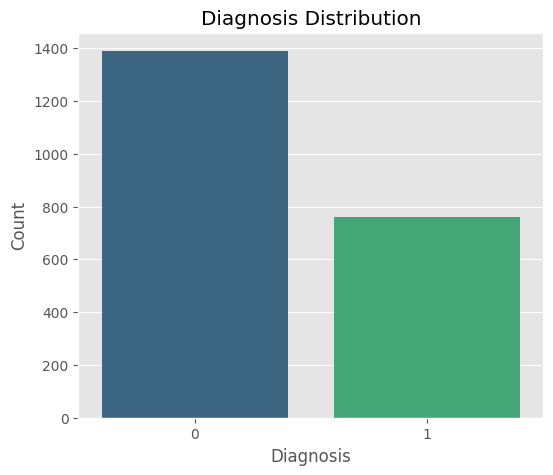

Diagnosis
0    64.634714
1    35.365286
Name: proportion, dtype: float64


In [10]:
plt.figure(figsize=(6,5))

sns.countplot(
    data=df,
    x="Diagnosis",
    palette="viridis"
)

plt.title("Diagnosis Distribution")

plt.xlabel("Diagnosis")

plt.ylabel("Count")

plt.show()

print(df["Diagnosis"].value_counts(normalize=True)*100)

**Correlation Heatmap**

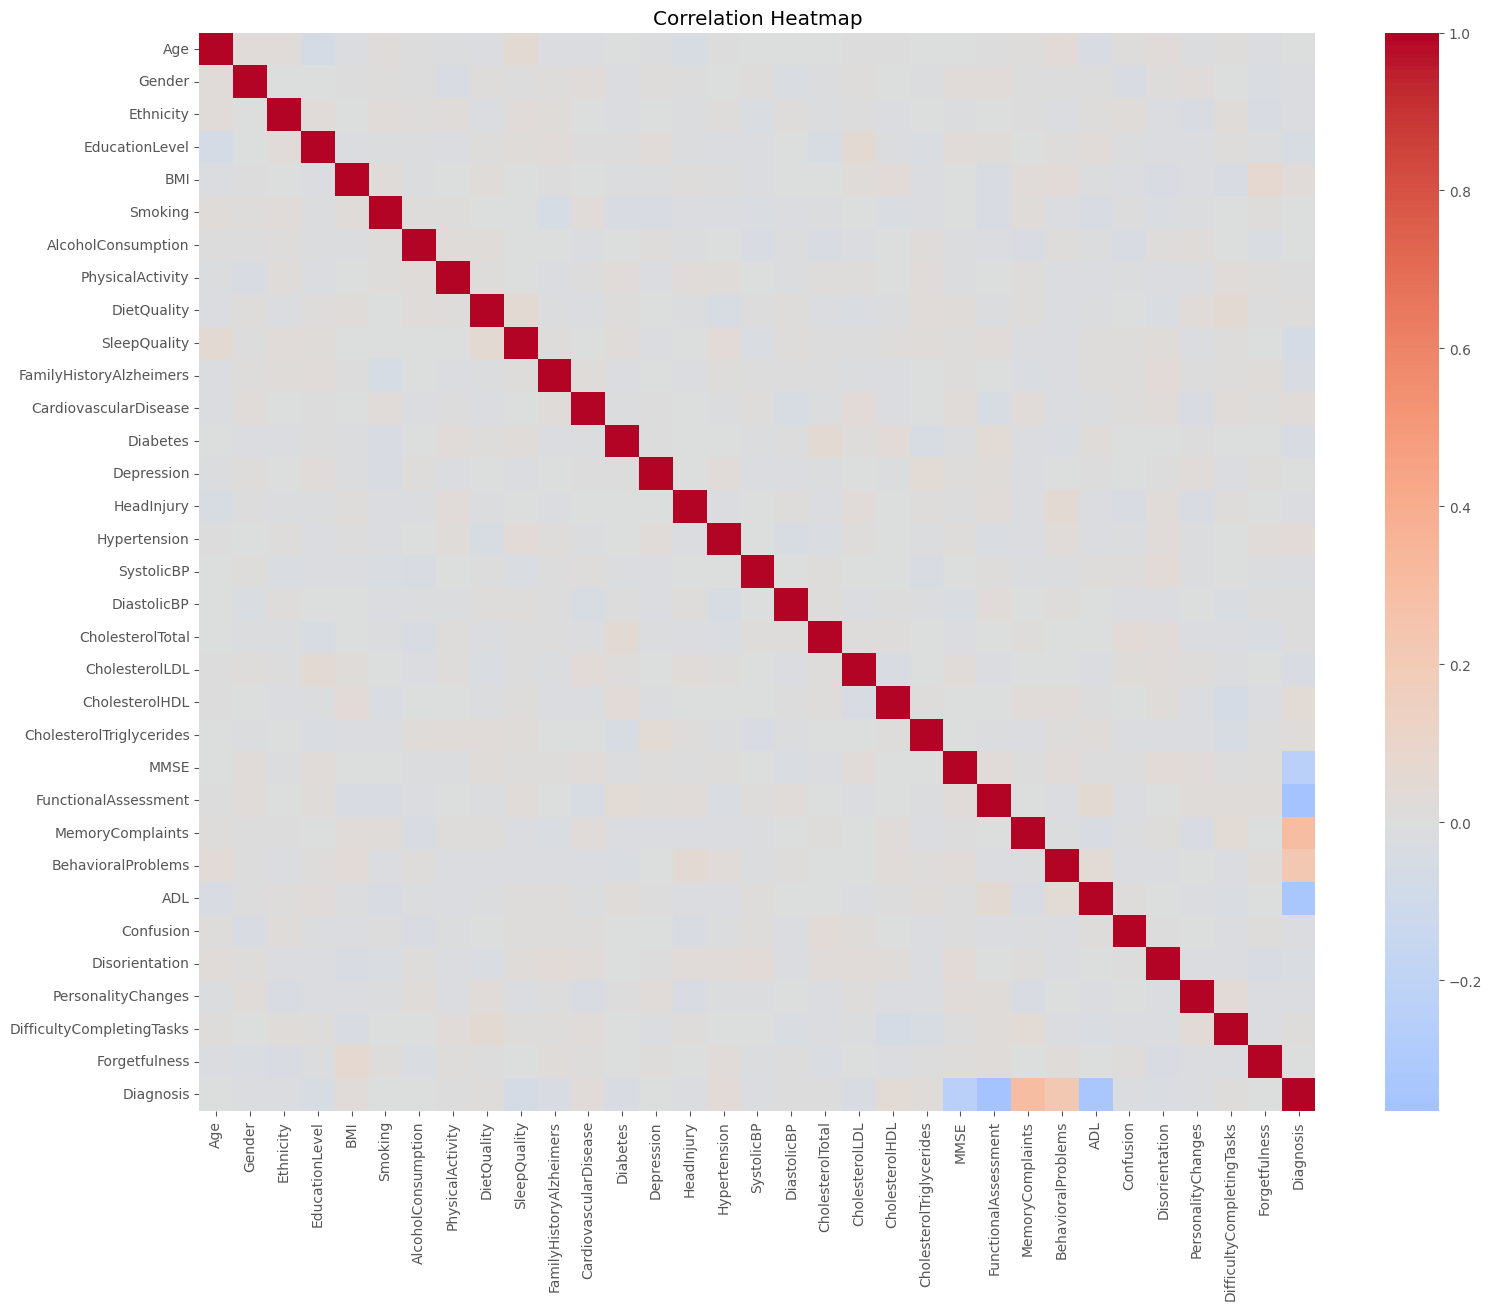

In [11]:
plt.figure(figsize=(18,14))

corr = df.corr()

sns.heatmap(
    corr,
    cmap="coolwarm",
    center=0
)

plt.title("Correlation Heatmap")

plt.show()

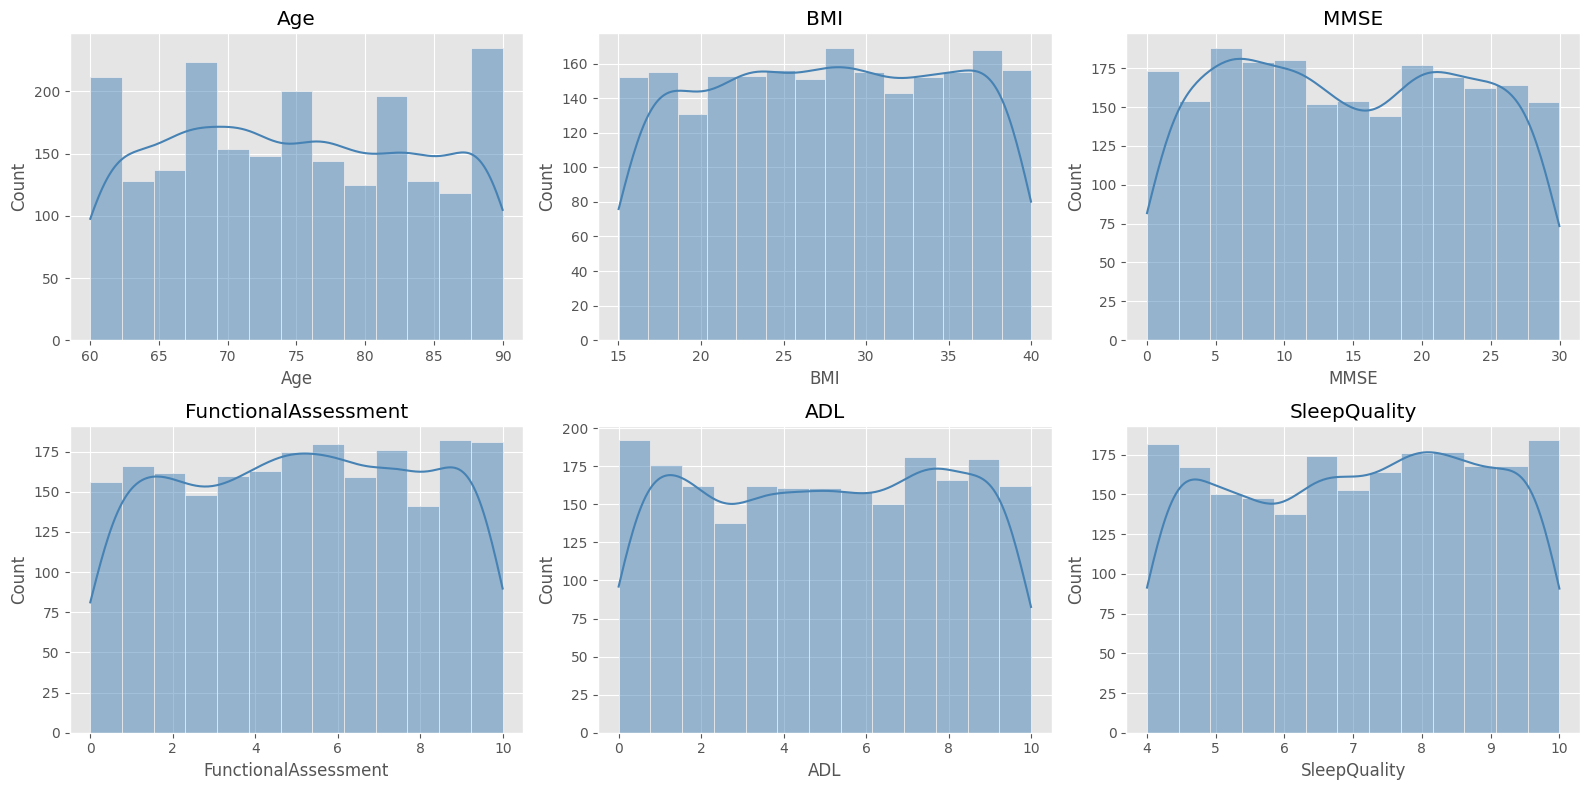

In [12]:
features = [

    "Age",

    "BMI",

    "MMSE",

    "FunctionalAssessment",

    "ADL",

    "SleepQuality"

]

fig, axes = plt.subplots(
    2,
    3,
    figsize=(16,8)
)

axes = axes.flatten()

for i,col in enumerate(features):

    sns.histplot(
        df[col],
        kde=True,
        ax=axes[i],
        color="steelblue"
    )

    axes[i].set_title(col)

plt.tight_layout()

plt.show()

**Boxplots**

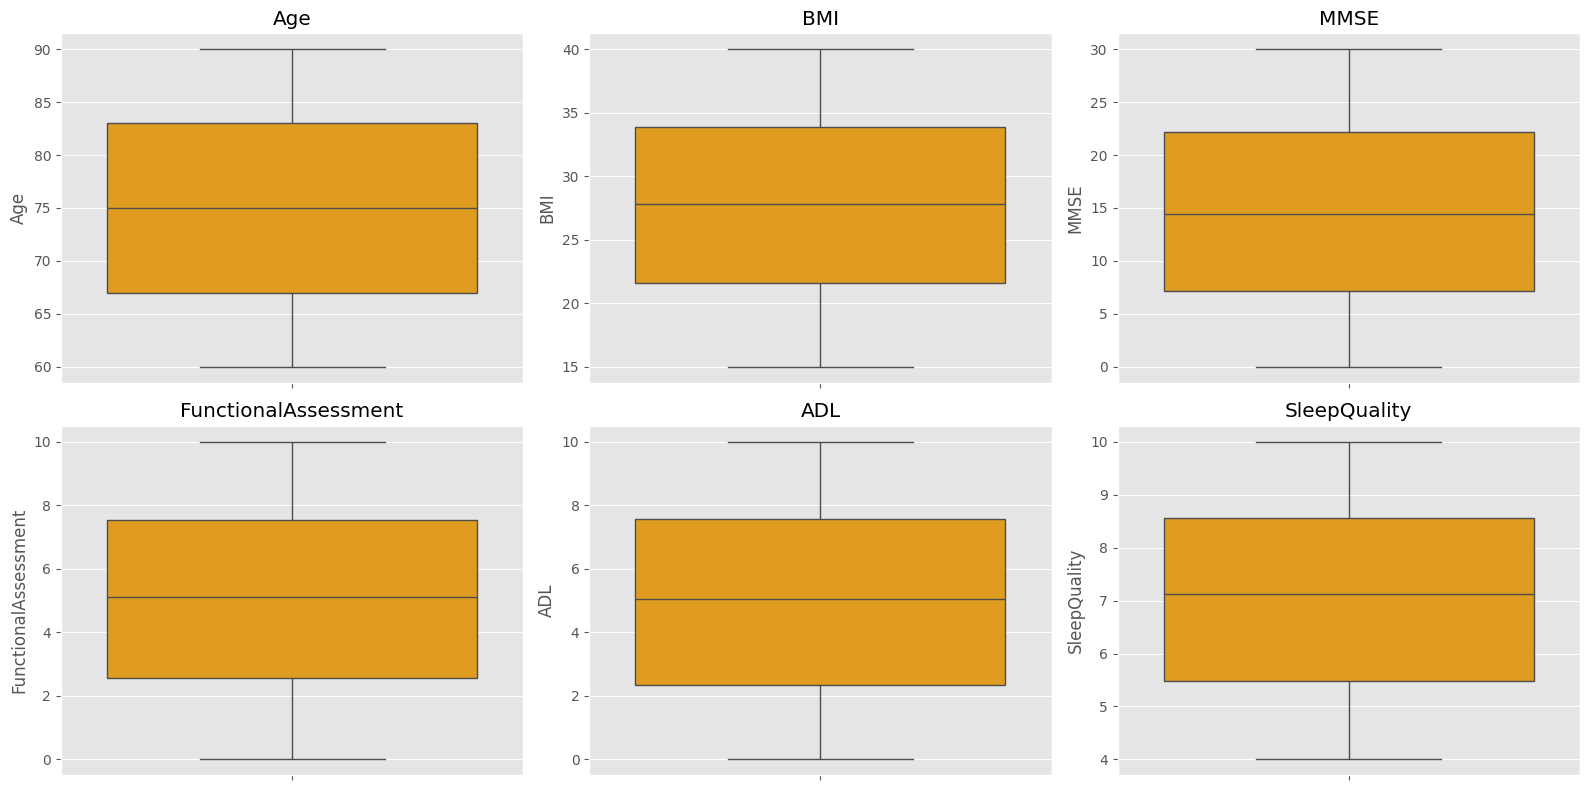

In [13]:
fig, axes = plt.subplots(
    2,
    3,
    figsize=(16,8)
)

axes = axes.flatten()

for i,col in enumerate(features):

    sns.boxplot(
        y=df[col],
        ax=axes[i],
        color="orange"
    )

    axes[i].set_title(col)

plt.tight_layout()

plt.show()

**Diagnosis & العمر**

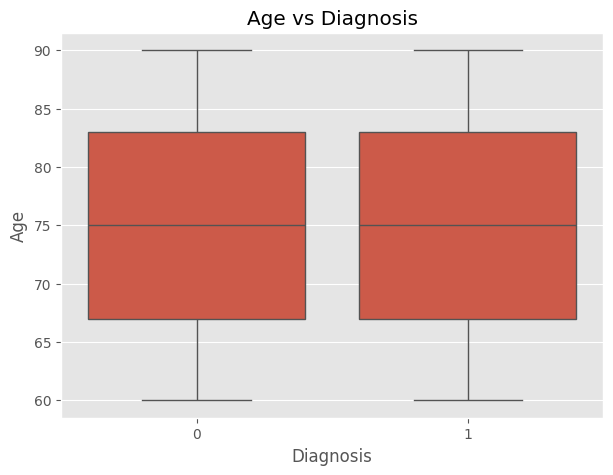

In [14]:
plt.figure(figsize=(7,5))

sns.boxplot(
    data=df,
    x="Diagnosis",
    y="Age"
)

plt.title("Age vs Diagnosis")

plt.show()

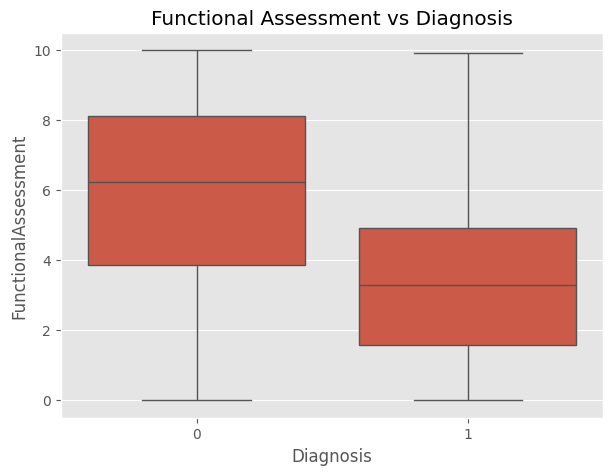

In [15]:
plt.figure(figsize=(7,5))

sns.boxplot(
    data=df,
    x="Diagnosis",
    y="FunctionalAssessment"
)

plt.title("Functional Assessment vs Diagnosis")

plt.show()

**Binary Features**

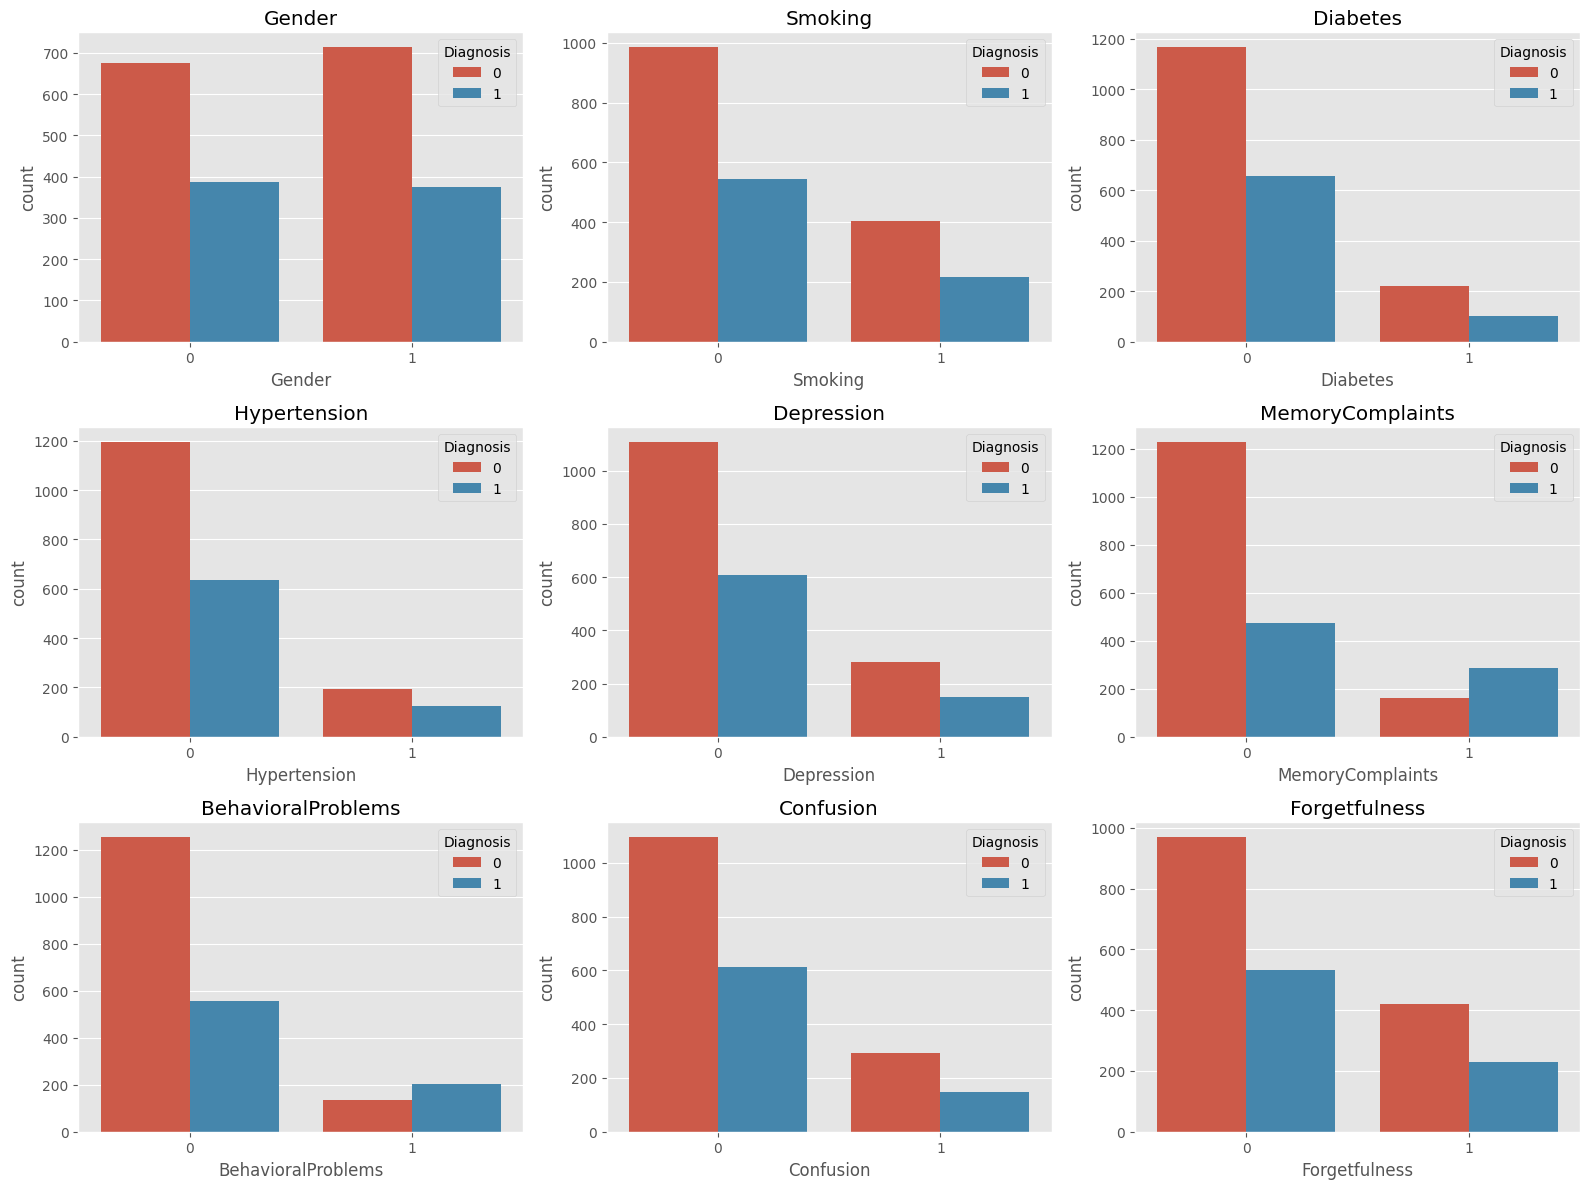

In [16]:
binary_features = [

    "Gender",

    "Smoking",

    "Diabetes",

    "Hypertension",

    "Depression",

    "MemoryComplaints",

    "BehavioralProblems",

    "Confusion",

    "Forgetfulness"

]

fig, axes = plt.subplots(
    3,
    3,
    figsize=(16,12)
)

axes = axes.flatten()

for i,col in enumerate(binary_features):

    sns.countplot(

        data=df,

        x=col,

        hue="Diagnosis",

        ax=axes[i]

    )

    axes[i].set_title(col)

plt.tight_layout()

plt.show()

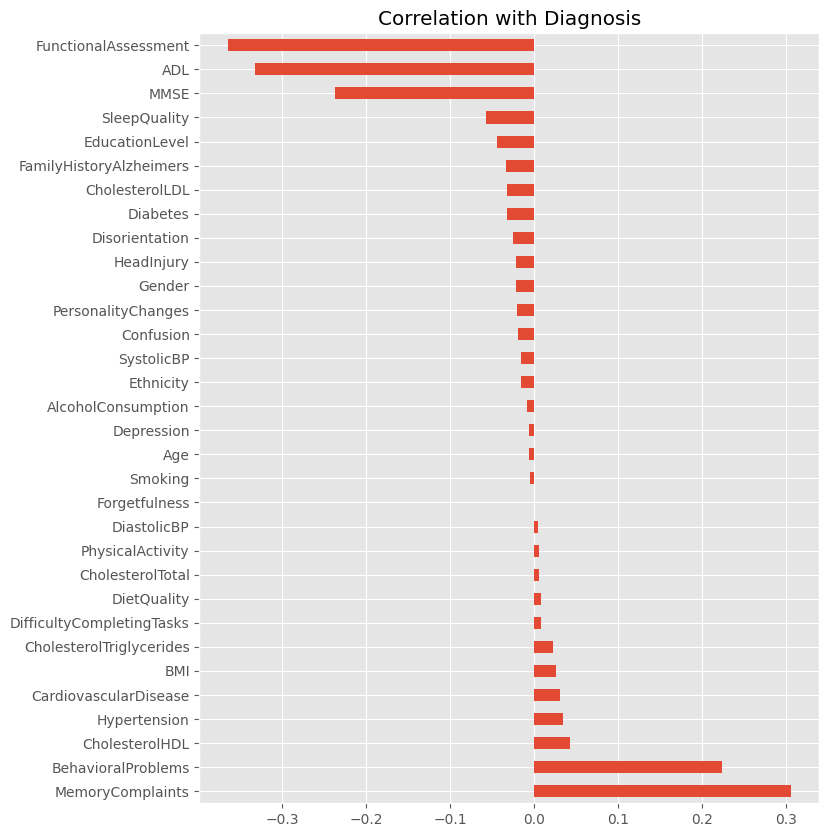

In [17]:
target_corr = (
    df.corr()["Diagnosis"]
    .sort_values(
        ascending=False
    )
)

plt.figure(figsize=(8,10))

target_corr.drop("Diagnosis").plot(
    kind="barh"
)

plt.title("Correlation with Diagnosis")

plt.show()

# **Data Cleaning & Preprocessing**

In [18]:
# ==========================================================
# Remove Duplicates
# ==========================================================

print("Shape Before :", df.shape)

df.drop_duplicates(inplace=True)

print("Shape After  :", df.shape)

Shape Before : (2149, 33)
Shape After  : (2149, 33)


In [19]:
# ==========================================================
# Handle Missing Values
# ==========================================================

numeric_columns = df.select_dtypes(include=["int64", "float64"]).columns.tolist()

numeric_columns.remove("Diagnosis")

imputer = SimpleImputer(strategy="median")

df[numeric_columns] = imputer.fit_transform(df[numeric_columns])

print(df.isnull().sum().sum())

0


In [20]:
# ==========================================================
# Split Features & Target
# ==========================================================

X = df.drop("Diagnosis", axis=1)

y = df["Diagnosis"]

print(X.shape)
print(y.shape)

(2149, 32)
(2149,)


In [21]:
# ==========================================================
# Train Test Split
# ==========================================================

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

In [22]:
# ==========================================================
# Feature Scaling
# ==========================================================

scaler = StandardScaler()

X_train = pd.DataFrame(
    scaler.fit_transform(X_train),
    columns=X_train.columns,
    index=X_train.index
)

X_test = pd.DataFrame(
    scaler.transform(X_test),
    columns=X_test.columns,
    index=X_test.index
)

print(X_train.head())

           Age    Gender  Ethnicity  EducationLevel       BMI   Smoking  \
780   1.230721 -1.009939   1.298741       -0.317924  0.065466 -0.642254   
1341 -1.430841  0.990159  -0.703533        1.903666  0.070065  1.557017   
820   0.010838 -1.009939  -0.703533       -1.428719 -0.316941 -0.642254   
857   1.563416 -1.009939  -0.703533       -1.428719 -0.567289 -0.642254   
593   0.121737  0.990159  -0.703533        0.792871  1.533521  1.557017   

      AlcoholConsumption  PhysicalActivity  DietQuality  SleepQuality  \
780             1.478214          0.571099    -1.276449      1.457443   
1341           -0.407432         -1.050032     0.340303     -1.135747   
820            -0.288334          1.628134    -1.119152      0.512803   
857            -1.418146         -1.257326     1.279730      1.255038   
593            -0.190409          1.188813     0.982253     -0.632116   

      FamilyHistoryAlzheimers  CardiovascularDisease  Diabetes  Depression  \
780                  1.726026   

In [23]:
# ==========================================================
# Save Scaler
# ==========================================================

with open("scaler.pkl", "wb") as f:
    pickle.dump(scaler, f)

# **Classification Models**

In [24]:
# ==========================================================
# Classification Models
# ==========================================================

import time

from sklearn.model_selection import cross_val_score

from sklearn.linear_model import LogisticRegression

from sklearn.neighbors import KNeighborsClassifier

from sklearn.tree import DecisionTreeClassifier

from sklearn.ensemble import (
    RandomForestClassifier,
    ExtraTreesClassifier,
    AdaBoostClassifier,
    GradientBoostingClassifier
)

from sklearn.naive_bayes import GaussianNB

from sklearn.svm import SVC

from xgboost import XGBClassifier

from lightgbm import LGBMClassifier
!pip install catboost
from catboost import CatBoostClassifier

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 97.1/97.1 MB 10.1 MB/s eta 0:00:00


# **Models Dictionary**

In [25]:
# ==========================================================
# Models
# ==========================================================

models = {

    "Logistic Regression": LogisticRegression(max_iter=1000),

    "KNN": KNeighborsClassifier(),

    "Decision Tree": DecisionTreeClassifier(random_state=42),

    "Random Forest": RandomForestClassifier(random_state=42),

    "Extra Trees": ExtraTreesClassifier(random_state=42),

    "AdaBoost": AdaBoostClassifier(random_state=42),

    "Gradient Boosting": GradientBoostingClassifier(random_state=42),

    "Gaussian NB": GaussianNB(),

    "SVM": SVC(
        probability=True,
        random_state=42
    ),

    "XGBoost": XGBClassifier(
        random_state=42,
        eval_metric="logloss"
    ),

    "LightGBM": LGBMClassifier(
        random_state=42,
        verbose=-1
    ),

    "CatBoost": CatBoostClassifier(
        verbose=0,
        random_state=42
    )

}

# **Evaluation Function**

In [26]:
# ==========================================================
# Evaluation Function
# ==========================================================

results = []

trained_models = {}

def evaluate_model(model, model_name):

    start = time.time()

    model.fit(X_train, y_train)

    end = time.time()

    trained_models[model_name] = model

    train_pred = model.predict(X_train)

    test_pred = model.predict(X_test)

    if hasattr(model, "predict_proba"):

        prob = model.predict_proba(X_test)[:,1]

    else:

        prob = model.decision_function(X_test)

    train_acc = accuracy_score(y_train, train_pred)

    test_acc = accuracy_score(y_test, test_pred)

    precision = precision_score(y_test, test_pred)

    recall = recall_score(y_test, test_pred)

    f1 = f1_score(y_test, test_pred)

    roc = roc_auc_score(y_test, prob)

    cv = cross_val_score(

        model,

        X_train,

        y_train,

        cv=5,

        scoring="accuracy",

        n_jobs=-1

    ).mean()

    results.append({

        "Model": model_name,

        "Train Accuracy": round(train_acc,4),

        "Test Accuracy": round(test_acc,4),

        "CV Score": round(cv,4),

        "Precision": round(precision,4),

        "Recall": round(recall,4),

        "F1 Score": round(f1,4),

        "ROC AUC": round(roc,4),

        "Training Time": round(end-start,2)

    })

    return model

# **Train All Models**

In [27]:
# ==========================================================
# Train All Models
# ==========================================================

results = []

trained_models = {}

for name, model in models.items():

    print(f"Training {name}...")

    evaluate_model(model, name)

print("\nAll Models Finished Successfully.")

Training Logistic Regression...
Training KNN...
Training Decision Tree...
Training Random Forest...
Training Extra Trees...
Training AdaBoost...
Training Gradient Boosting...
Training Gaussian NB...
Training SVM...
Training XGBoost...
Training LightGBM...
Training CatBoost...

All Models Finished Successfully.


# Comparison **Table**

In [28]:
comparison = pd.DataFrame(results)

comparison.sort_values(

    by="Test Accuracy",

    ascending=False,

    inplace=True

)

comparison.reset_index(

    drop=True,

    inplace=True

)

comparison

,Model,Train Accuracy,Test Accuracy,CV Score,Precision,Recall,F1 Score,ROC AUC,Training Time
0,LightGBM,1.0000,0.9535,0.9482,0.9459,0.9211,0.9333,0.9527,0.21
1,XGBoost,1.0000,0.9488,0.9459,0.9392,0.9145,0.9267,0.9467,0.56
2,CatBoost,0.9889,0.9488,0.9575,0.9333,0.9211,0.9272,0.9444,3.94
3,Gradient Boosting,0.9668,0.9465,0.9447,0.9272,0.9211,0.9241,0.9464,3.39
4,Random Forest,1.0000,0.9372,0.9308,0.9371,0.8816,0.9085,0.9391,1.61
5,AdaBoost,0.9424,0.9186,0.9308,0.8726,0.9013,0.8867,0.9384,1.00
6,Decision Tree,1.0000,0.9000,0.9034,0.8471,0.8750,0.8608,0.8943,0.10
7,Extra Trees,1.0000,0.8791,0.8546,0.8788,0.7632,0.8169,0.9197,0.72
8,SVM,0.9412,0.8349,0.8371,0.7914,0.7237,0.7560,0.8963,2.12
9,Logistic Regression,0.8511,0.8163,0.8400,0.7417,0.7368,0.7393,0.8854,0.02


# **Model Comparison Dashboard**

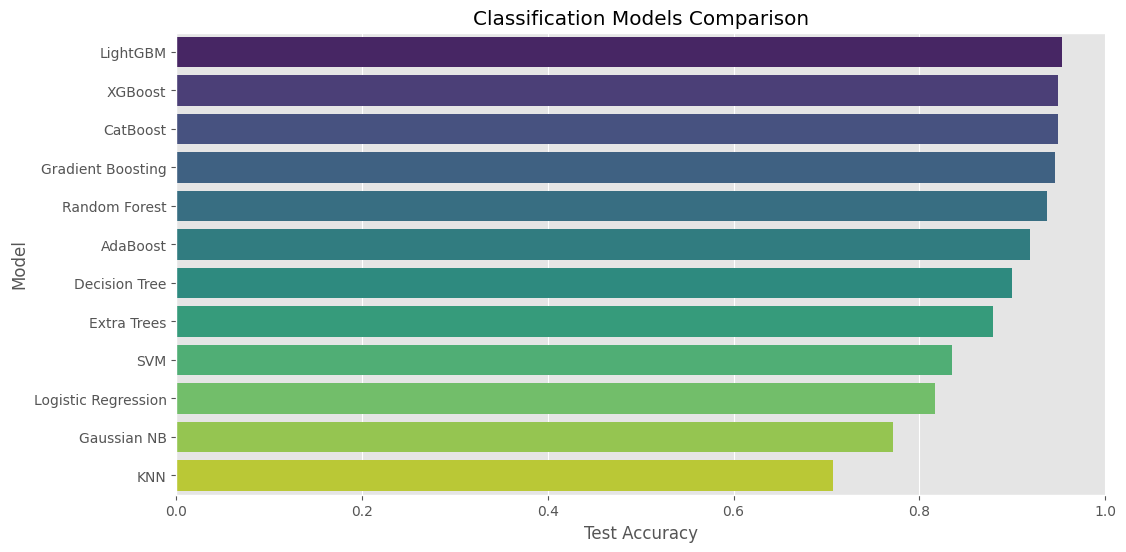

In [29]:
plt.figure(figsize=(12,6))

sns.barplot(

    data=comparison,

    y="Model",

    x="Test Accuracy",

    palette="viridis"

)

plt.title("Classification Models Comparison")

plt.show()

# **Train vs Test vs CV**

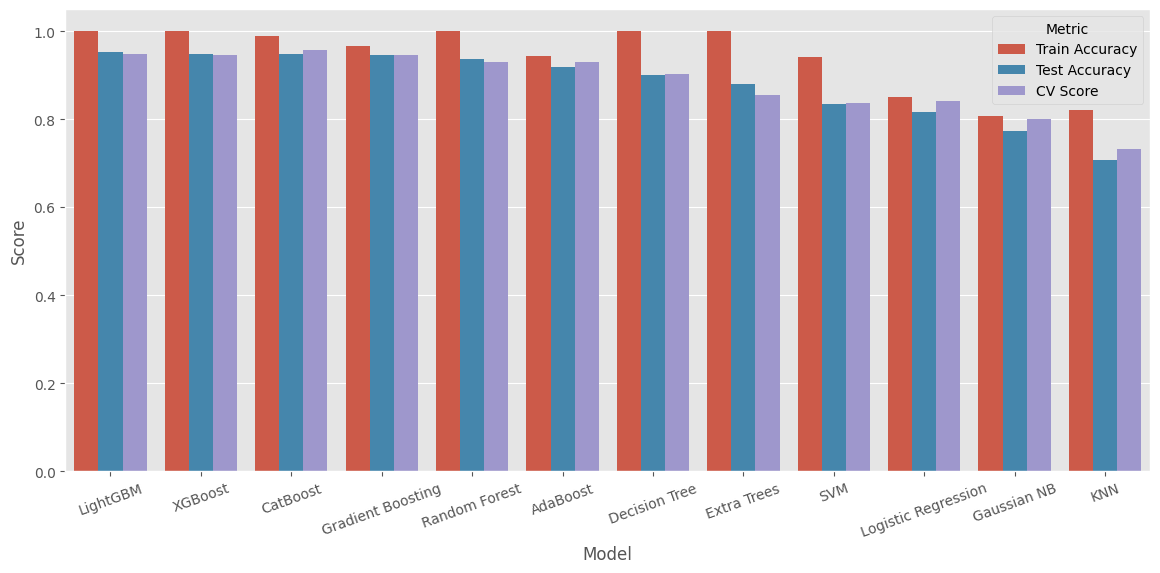

In [30]:
plot_df = comparison.melt(

    id_vars="Model",

    value_vars=[

        "Train Accuracy",

        "Test Accuracy",

        "CV Score"

    ],

    var_name="Metric",

    value_name="Score"

)

plt.figure(figsize=(14,6))

sns.barplot(

    data=plot_df,

    x="Model",

    y="Score",

    hue="Metric"

)

plt.xticks(rotation=20)

plt.show()

# **Best Model**

In [31]:
best_model_name = comparison.iloc[0]["Model"]

best_model = trained_models[best_model_name]

print("="*60)

print("Best Model :", best_model_name)

print("="*60)

Best Model : LightGBM


# **Smart RandomizedSearchCV**

In [32]:
# ==========================================================
# Hyperparameter Tuning
# ==========================================================

from sklearn.model_selection import RandomizedSearchCV
from scipy.stats import randint, uniform

# ==========================================================
# Choose Parameter Space Automatically
# ==========================================================

if best_model_name == "LightGBM":

    param_dist = {

        "n_estimators": randint(100,700),

        "learning_rate": uniform(0.01,0.2),

        "num_leaves": randint(20,120),

        "max_depth":[-1,5,10,15,20],

        "min_child_samples": randint(10,60),

        "subsample": uniform(0.6,0.4),

        "colsample_bytree": uniform(0.6,0.4)

    }

elif best_model_name == "XGBoost":

    param_dist = {

        "n_estimators": randint(100,700),

        "learning_rate": uniform(0.01,0.2),

        "max_depth": randint(3,12),

        "subsample": uniform(0.6,0.4),

        "colsample_bytree": uniform(0.6,0.4),

        "gamma": uniform(0,5)

    }

elif best_model_name == "CatBoost":

    param_dist = {

        "iterations": randint(200,700),

        "depth": randint(4,10),

        "learning_rate": uniform(0.01,0.2),

        "l2_leaf_reg": randint(1,10)

    }

elif best_model_name in ["Random Forest","Extra Trees"]:

    param_dist = {

        "n_estimators": randint(100,700),

        "max_depth":[None,5,10,15,20],

        "min_samples_split": randint(2,10),

        "min_samples_leaf": randint(1,5),

        "max_features":["sqrt","log2",None]

    }

else:

    raise ValueError(f"No parameter space defined for {best_model_name}")

# **Enable RandomizedSearchCV**

In [33]:
# ==========================================================
# Random Search
# ==========================================================

random_search = RandomizedSearchCV(

    estimator=best_model,

    param_distributions=param_dist,

    n_iter=40,

    cv=5,

    scoring="accuracy",

    random_state=42,

    n_jobs=-1,

    verbose=2

)

random_search.fit(
    X_train,
    y_train
)

Fitting 5 folds for each of 40 candidates, totalling 200 fits


RandomizedSearchCV(cv=5, estimator=LGBMClassifier(random_state=42, verbose=-1),
                   n_iter=40, n_jobs=-1,
                   param_distributions={'colsample_bytree': <scipy.stats._distn_infrastructure.rv_continuous_frozen object at 0x7930aff7d430>,
                                        'learning_rate': <scipy.stats._distn_infrastructure.rv_continuous_frozen object at 0x7930aeb81d90>,
                                        'max_depth': [-1, 5, 10, 15, 20],
                                        'min_child_..._frozen object at 0x7930ae7654f0>,
                                        'n_estimators': <scipy.stats._distn_infrastructure.rv_discrete_frozen object at 0x793102ca1d30>,
                                        'num_leaves': <scipy.stats._distn_infrastructure.rv_discrete_frozen object at 0x7930aebe7b30>,
                                        'subsample': <scipy.stats._distn_infrastructure.rv_continuous_frozen object at 0x7930aefdb710>},
                   random_state=42, scoring='accuracy', verbose=2)

In [34]:
print("="*60)

print("Best CV Score")

print(random_search.best_score_)

print()

print("Best Parameters")

print(random_search.best_params_)

Best CV Score
0.9528883314122991

Best Parameters
{'colsample_bytree': np.float64(0.7301598792637071), 'learning_rate': np.float64(0.15929828102360485), 'max_depth': 10, 'min_child_samples': 26, 'n_estimators': 132, 'num_leaves': 67, 'subsample': np.float64(0.637469907131237)}


In [35]:
best_tuned_model = random_search.best_estimator_

In [36]:
y_pred = best_tuned_model.predict(X_test)

y_prob = best_tuned_model.predict_proba(X_test)[:,1]

print("Accuracy :",accuracy_score(y_test,y_pred))

print("Precision :",precision_score(y_test,y_pred))

print("Recall :",recall_score(y_test,y_pred))

print("F1 :",f1_score(y_test,y_pred))

print("ROC AUC :",roc_auc_score(y_test,y_prob))

Accuracy : 0.9511627906976744
Precision : 0.9395973154362416
Recall : 0.9210526315789473
F1 : 0.9302325581395349
ROC AUC : 0.9434873154108293


# **Comparison Before & After**

In [37]:
before = comparison.iloc[0]

after = {

    "Model":"After Random Search",

    "Accuracy":accuracy_score(y_test,y_pred),

    "Precision":precision_score(y_test,y_pred),

    "Recall":recall_score(y_test,y_pred),

    "F1":f1_score(y_test,y_pred),

    "ROC AUC":roc_auc_score(y_test,y_prob)

}

compare_random = pd.DataFrame({

    "Metric":[

        "Accuracy",

        "Precision",

        "Recall",

        "F1",

        "ROC AUC"

    ],

    "Before":[

        before["Test Accuracy"],

        before["Precision"],

        before["Recall"],

        before["F1 Score"],

        before["ROC AUC"]

    ],

    "After":[

        after["Accuracy"],

        after["Precision"],

        after["Recall"],

        after["F1"],

        after["ROC AUC"]

    ]

})

compare_random

,Metric,Before,After
0,Accuracy,0.9535,0.951163
1,Precision,0.9459,0.939597
2,Recall,0.9211,0.921053
3,F1,0.9333,0.930233
4,ROC AUC,0.9527,0.943487


In [41]:
best_tuned_model

LGBMClassifier(colsample_bytree=np.float64(0.7301598792637071),
               learning_rate=np.float64(0.15929828102360485), max_depth=10,
               min_child_samples=26, n_estimators=132, num_leaves=67,
               random_state=42, subsample=np.float64(0.637469907131237),
               verbose=-1)

# **Feature Importance**

In [53]:
# ==========================================================
# Feature Importance
# ==========================================================

importance = pd.DataFrame({

    "Feature": X_train.columns,

    "Importance": best_tuned_model.feature_importances_

})

importance = importance.sort_values(
    by="Importance",
    ascending=False
).reset_index(drop=True)

importance.head(20)

,Feature,Importance
0,ADL,595
1,FunctionalAssessment,553
2,MMSE,497
3,DietQuality,496
4,CholesterolTotal,379
5,SleepQuality,379
6,CholesterolTriglycerides,365
7,CholesterolHDL,355
8,AlcoholConsumption,322
9,CholesterolLDL,311


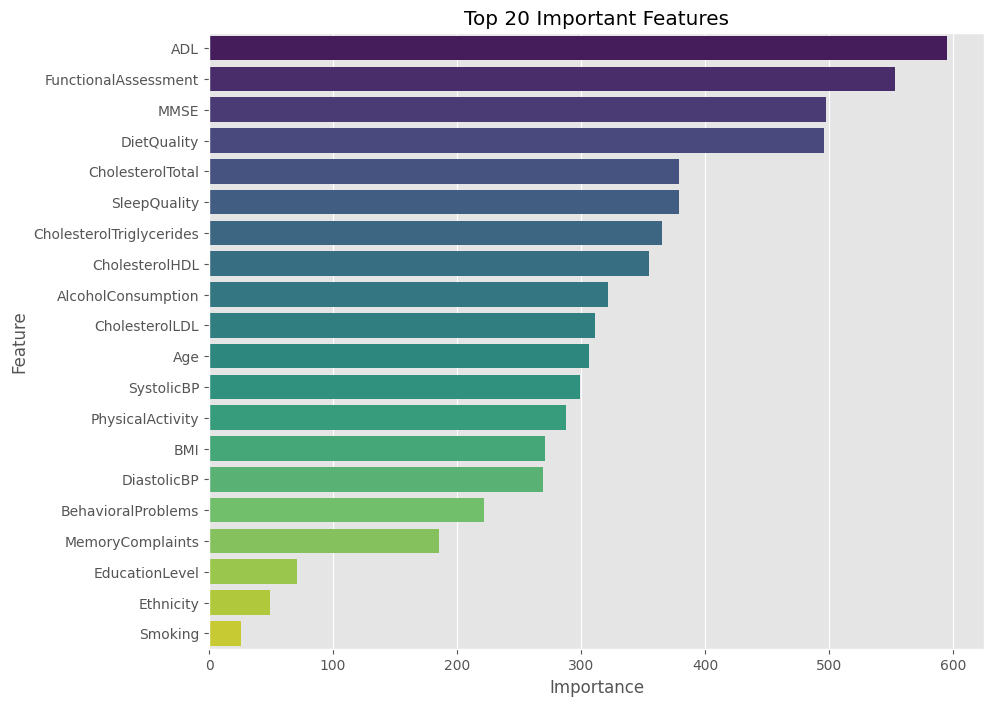

In [54]:
plt.figure(figsize=(10,8))

sns.barplot(

    data=importance.head(20),

    x="Importance",

    y="Feature",

    palette="viridis"

)

plt.title("Top 20 Important Features")

plt.show()

# **Smart Feature Selection**

In [55]:
# ==========================================================
# Feature Selection Comparison
# ==========================================================

feature_results = []

feature_models = {}

numbers = [

    5,

    10,

    15,

    20,

    len(X_train.columns)

]

In [56]:
for top in numbers:

    selected = importance.head(top)["Feature"].tolist()

    X_train_new = X_train[selected]

    X_test_new = X_test[selected]

    model = LGBMClassifier(



        **best_tuned_model.get_params()

    )

    model.fit(

        X_train_new,

        y_train

    )

    pred = model.predict(X_test_new)

    prob = model.predict_proba(
        X_test_new
    )[:,1]

    feature_models[top] = model

    feature_results.append({

        "Top Features":top,

        "Accuracy":accuracy_score(y_test,pred),

        "Precision":precision_score(y_test,pred),

        "Recall":recall_score(y_test,pred),

        "F1":f1_score(y_test,pred),

        "ROC":roc_auc_score(y_test,prob)

    })

In [57]:
feature_results = pd.DataFrame(feature_results)

feature_results.sort_values(

    by="Accuracy",

    ascending=False,

    inplace=True

)

feature_results.reset_index(

    drop=True,

    inplace=True
)

feature_results

,Top Features,Accuracy,Precision,Recall,F1,ROC
0,32,0.948837,0.933333,0.921053,0.927152,0.945333
1,20,0.948837,0.933333,0.921053,0.927152,0.945002
2,5,0.823256,0.796875,0.671053,0.728571,0.873982
3,10,0.816279,0.792000,0.651316,0.714801,0.856494
4,15,0.811628,0.798319,0.625000,0.701107,0.851784


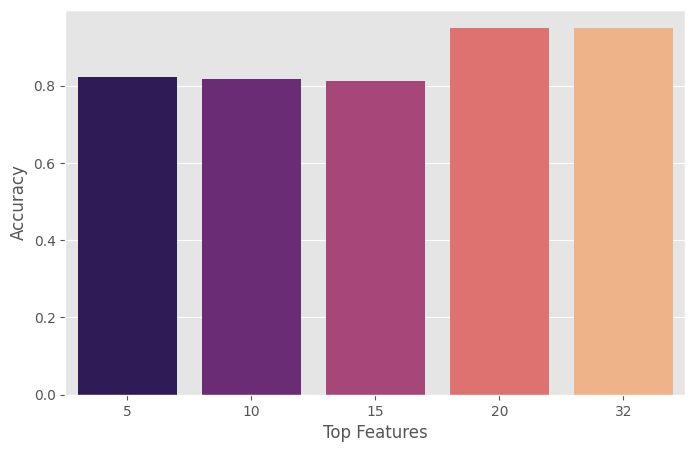

In [58]:
plt.figure(figsize=(8,5))

sns.barplot(

    data=feature_results,

    x="Top Features",

    y="Accuracy",

    palette="magma"

)

plt.show()

In [59]:
best_number = int(feature_results.iloc[0]["Top Features"])

print(best_number)

32


In [80]:
best_features = importance.head(20)["Feature"].tolist()

best_features

['ADL', 'FunctionalAssessment', 'MMSE', 'DietQuality', 'CholesterolTotal']

In [81]:
X_train_best = X_train[best_features]

X_test_best = X_test[best_features]

In [82]:
final_model = LGBMClassifier(

    **best_tuned_model.get_params()

)

final_model.fit(

    X_train_best,

    y_train

)

LGBMClassifier(colsample_bytree=np.float64(0.7301598792637071),
               learning_rate=np.float64(0.15929828102360485), max_depth=10,
               min_child_samples=26, n_estimators=132, num_leaves=67,
               random_state=42, subsample=np.float64(0.637469907131237),
               verbose=-1)

In [83]:
prediction = final_model.predict(
    X_test_best
)

probability = final_model.predict_proba(
    X_test_best
)[:,1]

In [84]:
print("Accuracy :",accuracy_score(y_test,prediction))

print("Precision :",precision_score(y_test,prediction))

print("Recall :",recall_score(y_test,prediction))

print("F1 :",f1_score(y_test,prediction))

print("ROC :",roc_auc_score(y_test,probability))

Accuracy : 0.8232558139534883
Precision : 0.796875
Recall : 0.6710526315789473
F1 : 0.7285714285714285
ROC : 0.8739823930329421


In [85]:
print(classification_report(

    y_test,

    prediction

))

              precision    recall  f1-score   support

           0       0.83      0.91      0.87       278
           1       0.80      0.67      0.73       152

    accuracy                           0.82       430
   macro avg       0.82      0.79      0.80       430
weighted avg       0.82      0.82      0.82       430



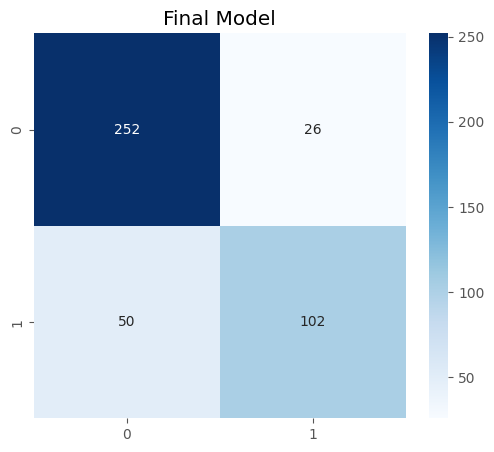

In [86]:
cm = confusion_matrix(

    y_test,

    prediction

)

plt.figure(figsize=(6,5))

sns.heatmap(

    cm,

    annot=True,

    fmt="d",

    cmap="Blues"

)

plt.title("Final Model")

plt.show()

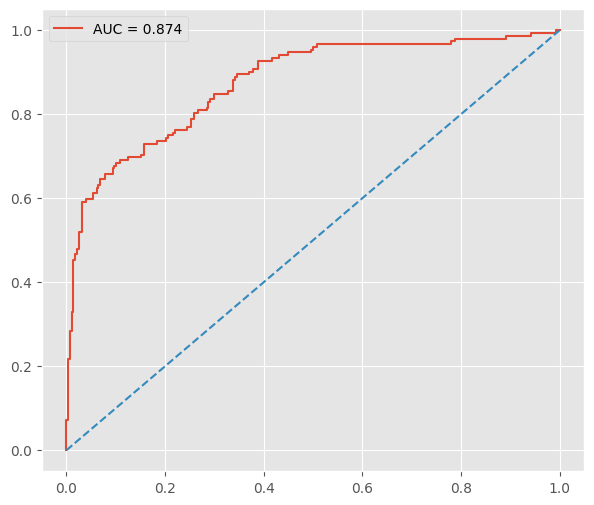

In [87]:
fpr,tpr,_ = roc_curve(

    y_test,

    probability

)

plt.figure(figsize=(7,6))

plt.plot(

    fpr,

    tpr,

    label=f"AUC = {roc_auc_score(y_test,probability):.3f}"

)

plt.plot(

    [0,1],

    [0,1],

    "--"

)

plt.legend()

plt.show()

# **Save Everything**

In [88]:
# ==========================================================
# Save Final Model Files
# ==========================================================

import pickle

with open("final_model.pkl", "wb") as f:
    pickle.dump(final_model, f)

with open("scaler.pkl", "wb") as f:
    pickle.dump(scaler, f)

with open("imputer.pkl", "wb") as f:
    pickle.dump(imputer, f)

with open("best_features.pkl", "wb") as f:
    pickle.dump(best_features, f)

print("All Files Saved Successfully.")

All Files Saved Successfully.


In [89]:
with open("all_features.pkl", "wb") as f:
    pickle.dump(list(X.columns), f)

In [95]:
# ==========================================
# Default Values for Missing Inputs
# ==========================================

default_values = {}

for col in best_features:

    if df[col].nunique() <= 2:
        # Binary Feature
        default_values[col] = df[col].mode()[0]
    else:
        # Numeric Feature
        default_values[col] = df[col].mean()

import pickle

with open("default_values.pkl", "wb") as f:
    pickle.dump(default_values, f)

print(default_values)

{'ADL': np.float64(4.982958398766785), 'FunctionalAssessment': np.float64(5.080054971172), 'MMSE': np.float64(14.7551319782826), 'DietQuality': np.float64(4.993137913666496), 'CholesterolTotal': np.float64(225.19751887796377)}


In [96]:
import gradio as gr
import pickle
import pandas as pd

with open("final_model.pkl", "rb") as f:
    model = pickle.load(f)

with open("scaler.pkl", "rb") as f:
    scaler = pickle.load(f)

with open("best_features.pkl", "rb") as f:
    best_features = pickle.load(f)

with open("all_features.pkl", "rb") as f:
    all_features = pickle.load(f)

In [97]:
top5 = best_features[:5]

print(top5)

['ADL', 'FunctionalAssessment', 'MMSE', 'DietQuality', 'CholesterolTotal']


In [98]:
def predict_alzheimer(
    adl,
    functional,
    mmse,
    diet,
    cholesterol
):

    sample = default_values.copy()

    sample["ADL"] = adl
    sample["FunctionalAssessment"] = functional
    sample["MMSE"] = mmse
    sample["DietQuality"] = diet
    sample["CholesterolTotal"] = cholesterol

    sample = pd.DataFrame([sample])

    sample = sample[best_features]

    sample = scaler.transform(sample)

    pred = final_model.predict(sample)[0]

    prob = final_model.predict_proba(sample)[0][1]

    if pred == 1:

        return f"""
🧠 Alzheimer's Disease

Probability : {prob:.2%}
"""

    else:

        return f"""
✅ Healthy

Probability : {(1-prob):.2%}
"""

In [99]:
inputs = [

    gr.Slider(
        minimum=0,
        maximum=10,
        step=0.1,
        value=5,
        label="ADL"
    ),

    gr.Slider(
        minimum=0,
        maximum=10,
        step=0.1,
        value=5,
        label="Functional Assessment"
    ),

    gr.Slider(
        minimum=0,
        maximum=30,
        step=0.1,
        value=20,
        label="MMSE"
    ),

    gr.Slider(
        minimum=0,
        maximum=10,
        step=0.1,
        value=5,
        label="Diet Quality"
    ),

    gr.Slider(
        minimum=100,
        maximum=400,
        step=1,
        value=200,
        label="Total Cholesterol"
    )

]

In [100]:
demo = gr.Interface(

    fn=predict_alzheimer,

    inputs=inputs,

    outputs=gr.Textbox(label="Prediction"),

    title="🧠 Alzheimer's Disease Prediction",

    description="""
Enter the patient's medical information and click Submit.
The model predicts whether the patient is likely to have Alzheimer's disease.
""",

    theme=gr.themes.Soft()

)

demo.launch()

It looks like you are running Gradio on a hosted Jupyter notebook, which requires `share=True`. Automatically setting `share=True` (you can turn this off by setting `share=False` in `launch()` explicitly).

Colab notebook detected. To show errors in colab notebook, set debug=True in launch()
* Running on public URL: https://057d27d97a53628244.gradio.live

This share link is temporary and will last for up to 1 week (best effort). For free permanent hosting and GPU upgrades, run `gradio deploy` from the terminal in the working directory to deploy to Hugging Face Spaces (https://huggingface.co/spaces)


In [79]:
print(best_number)

print(best_features)

print(len(best_features))

32
['ADL', 'FunctionalAssessment', 'MMSE', 'DietQuality', 'CholesterolTotal', 'SleepQuality', 'CholesterolTriglycerides', 'CholesterolHDL', 'AlcoholConsumption', 'CholesterolLDL', 'Age', 'SystolicBP', 'PhysicalActivity', 'BMI', 'DiastolicBP', 'BehavioralProblems', 'MemoryComplaints', 'EducationLevel', 'Ethnicity', 'Smoking', 'Gender', 'CardiovascularDisease', 'Depression', 'Disorientation', 'DifficultyCompletingTasks', 'PersonalityChanges', 'Forgetfulness', 'Hypertension', 'Diabetes', 'Confusion', 'FamilyHistoryAlzheimers', 'HeadInjury']
32


In [94]:
importance.head(10)

,Feature,Importance
0,ADL,595
1,FunctionalAssessment,553
2,MMSE,497
3,DietQuality,496
4,CholesterolTotal,379
5,SleepQuality,379
6,CholesterolTriglycerides,365
7,CholesterolHDL,355
8,AlcoholConsumption,322
9,CholesterolLDL,311
